# FAA Reddit Analysis for Safety Signals and Complaints

This notebook follows the same overall analytic structure as the Twitter notebook, but it is adapted to the Reddit scrape. The focus is on pure notebook-native analysis output: pandas tables, inline matplotlib plots, and model results produced directly by notebook code cells.

Unlike the earlier Reddit notebook versions, this one does **not** retrieve image assets from a folder to show results. The plots and tables are generated directly from the code in the notebook.


In [1]:
from pathlib import Path
import html
import math
import os
import re
import textwrap
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
from hdbscan import HDBSCAN
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.manifold import Isomap, MDS, TSNE
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from transformers import pipeline

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 220)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

ROOT = Path(r"C:\Users\HetongWang\Documents\Playground")
DOWNLOAD_DIR = Path(r"E:\ChromeDownload")

PRIMARY = "#203E6E"
SECONDARY = "#C97C5D"
ACCENT = "#7BA59D"
GOLD = "#D8B46B"
RED = "#B55454"
PURPLE = "#7C6C8F"
GRAY = "#5E6770"
NOISE_COLOR = "#D6DCE5"
CLUSTER_COLORS = [
    "#1F77B4",
    "#D62728",
    "#2CA02C",
    "#9467BD",
    "#FF7F0E",
    "#17BECF",
    "#8C564B",
    "#E377C2",
    "#BCBD22",
]

THEME_COLORS = {
    "staffing": PRIMARY,
    "recruitment": SECONDARY,
    "safety_oversight": RED,
    "operations": GOLD,
    "incident": PURPLE,
    "working_conditions": ACCENT,
    "other": "#A3ABB5",
}

URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
MARKDOWN_LINK_PATTERN = re.compile(r"\[([^\]]+)\]\(([^\)]+)\)")
EXTRA_SPACE_PATTERN = re.compile(r"\s+")
NON_TEXT_PATTERN = re.compile(r"[^a-z0-9'\s]")
ARTIFACT_PATTERN = re.compile(r"\b(?:http|https|www|amp|gif|image|thumbnail)\b")

CORE_FAA_PATTERN = re.compile(
    r"\b(?:faa|atc|air traffic(?: control)?|controller(?:s)?|natca|laguardia|lga|dca)\b",
    re.IGNORECASE,
)
FAA_AUX_PATTERN = re.compile(
    r"\b(?:runway|staffing|understaffed|shortage|tower|ground stop|air canada|helicopter|overtime|fatigue)\b",
    re.IGNORECASE,
)
AVIATION_COMMUNITY_PATTERN = re.compile(
    r"(?:atc|aviation|flying|aircrash|fearofflying|flightattendants|delta|united|fednews|drones|airlines|canada|montreal)",
    re.IGNORECASE,
)

KEYWORD_GROUPS = {
    "staffing": [
        "staffing",
        "understaffed",
        "shortage",
        "shortages",
        "short staffed",
        "controller shortage",
        "tower staffing",
    ],
    "recruitment": [
        "hire",
        "hiring",
        "recruit",
        "recruitment",
        "academy",
        "trainee",
        "candidate",
        "gamer",
        "qualified",
    ],
    "safety_oversight": [
        "safety",
        "oversight",
        "investigation",
        "ntsb",
        "reform",
        "risk",
        "unsafe",
    ],
    "operations": [
        "delay",
        "delays",
        "cancel",
        "ground stop",
        "ground delay",
        "queue",
        "shutdown",
        "traffic",
        "flights",
    ],
    "incident": [
        "crash",
        "collision",
        "runway",
        "laguardia",
        "lga",
        "dca",
        "helicopter",
        "air canada",
        "near miss",
    ],
    "working_conditions": [
        "fatigue",
        "overtime",
        "pay",
        "retire",
        "retirement",
        "shift",
        "schedule",
        "sleep",
        "burnout",
    ],
}

THEME_PRIORITY = [
    "incident",
    "operations",
    "safety_oversight",
    "working_conditions",
    "recruitment",
    "staffing",
]

CUSTOM_STOP_WORDS = sorted(
    ENGLISH_STOP_WORDS.union(
        {
            "faa",
            "atc",
            "air",
            "traffic",
            "control",
            "controller",
            "controllers",
            "aviation",
            "airport",
            "airports",
            "flight",
            "flights",
            "mirror",
            "tweet",
            "firstsquawk",
            "squawk",
            "breaking",
            "people",
            "just",
            "like",
            "say",
            "year",
            "work",
            "want",
            "time",
            "make",
            "look",
            "thing",
            "things",
            "good",
            "know",
        }
    )
)


def summarize_columns(frame):
    rows = []
    for col in frame.columns:
        series = frame[col]
        row = {
            "column": col,
            "dtype": str(series.dtype),
            "missing_count": int(series.isna().sum()),
            "missing_pct": round(100 * series.isna().mean(), 2),
            "n_unique": int(series.nunique(dropna=True)),
        }
        if pd.api.types.is_numeric_dtype(series):
            row["zero_pct"] = round(100 * (series.fillna(0) == 0).mean(), 2)
        else:
            row["zero_pct"] = np.nan
        rows.append(row)
    return (
        pd.DataFrame(rows)
        .sort_values(["missing_pct", "n_unique"], ascending=[False, False])
        .reset_index(drop=True)
    )


def basic_clean(text):
    text = html.unescape(str(text))
    text = text.replace("\n", " ")
    text = MARKDOWN_LINK_PATTERN.sub(r" \1 ", text)
    text = URL_PATTERN.sub(" ", text)
    text = text.lower()
    text = NON_TEXT_PATTERN.sub(" ", text)
    text = ARTIFACT_PATTERN.sub(" ", text)
    return EXTRA_SPACE_PATTERN.sub(" ", text).strip()


def get_top_component_terms(model, vocab, component_idx, top_n=10):
    weights = model.components_[component_idx]
    order = np.argsort(np.abs(weights))[::-1][:top_n]
    return list(vocab[order])


def get_top_ngrams(text_series, ngram_range=(1, 1), min_df=5, top_n=20):
    vectorizer = CountVectorizer(
        stop_words=CUSTOM_STOP_WORDS,
        ngram_range=ngram_range,
        min_df=min_df,
    )
    matrix = vectorizer.fit_transform(text_series)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    vocab = vectorizer.get_feature_names_out()
    order = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({"ngram": vocab[order], "count": counts[order]})


def assign_keyword_labels(text):
    labels = []
    for label, terms in KEYWORD_GROUPS.items():
        if any(term in text for term in terms):
            labels.append(label)
    return labels


def choose_theme(labels):
    for theme in THEME_PRIORITY:
        if theme in labels:
            return theme
    return "other"


def plot_embedding(embedding, title, hue_values):
    fig, ax = plt.subplots(figsize=(6.2, 4.8))
    labels = pd.Series(hue_values).reset_index(drop=True)
    for label in sorted(labels.unique()):
        mask = labels == label
        ax.scatter(
            embedding[mask.to_numpy(), 0],
            embedding[mask.to_numpy(), 1],
            s=22,
            alpha=0.78,
            color=THEME_COLORS.get(label, "#999999"),
            label=label.replace("_", " "),
        )
    ax.set_title(title, fontsize=12, color=PRIMARY)
    ax.legend(loc="upper right", fontsize=7, frameon=False)
    plt.tight_layout()
    plt.show()


def plot_density_clusters(embedding, labels, title):
    fig, ax = plt.subplots(figsize=(6.5, 5.0))
    labels = np.asarray(labels)

    noise_mask = labels == -1
    if noise_mask.any():
        ax.scatter(
            embedding[noise_mask, 0],
            embedding[noise_mask, 1],
            s=20,
            alpha=0.40,
            color=NOISE_COLOR,
            label=f"Noise ({noise_mask.mean() * 100:.1f}%)",
            zorder=1,
        )

    non_noise_labels = [label for label in sorted(np.unique(labels)) if label != -1]
    for idx, label in enumerate(non_noise_labels):
        mask = labels == label
        ax.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            s=28,
            alpha=0.82,
            color=CLUSTER_COLORS[idx % len(CLUSTER_COLORS)],
            edgecolors="white",
            linewidth=0.35,
            label=f"Cluster {label} (n={int(mask.sum())})",
            zorder=2,
        )

    ax.set_title(title, fontsize=12, color=PRIMARY)
    ax.legend(loc="upper right", fontsize=7, frameon=False)
    plt.tight_layout()
    plt.show()


def get_top_words(weights, vocab, n=10):
    order = np.argsort(weights)[::-1][:n]
    return list(vocab[order])


def make_topic_labels(topic_words, topic_theme_matrix, max_themes=2, max_words=2):
    word_frequency = Counter(word for words in topic_words for word in words)
    generic_label_words = {
        "need",
        "use",
        "new",
        "issue",
        "happen",
        "day",
        "high",
        "start",
        "think",
        "change",
        "group",
        "program",
        "state",
        "run",
    }

    labels = {}
    used_labels = set()

    for topic_idx, words in enumerate(topic_words):
        theme_row = topic_theme_matrix.loc[topic_idx].sort_values(ascending=False)
        top_themes = [
            theme.replace("_", " ")
            for theme in theme_row.index
            if theme != "other" and theme_row[theme] >= 0.10
        ][:max_themes]

        distinctive_words = [
            word.replace("_", " ")
            for word in words
            if word_frequency[word] == 1 and word not in generic_label_words
        ][:max_words]

        fallback_words = [
            word.replace("_", " ")
            for word in words
            if word not in generic_label_words
        ][:max_words + 2]

        parts = []
        parts.extend(top_themes)
        for word in distinctive_words:
            if word not in parts:
                parts.append(word)

        if not parts:
            parts = fallback_words[:max_words]

        label = " / ".join(parts[:3]) if parts else f"topic {topic_idx}"

        if label in used_labels:
            for word in fallback_words:
                candidate_parts = parts.copy()
                if word not in candidate_parts:
                    candidate_parts.append(word)
                candidate = " / ".join(candidate_parts[:4])
                if candidate not in used_labels:
                    label = candidate
                    break

        labels[topic_idx] = label
        used_labels.add(label)

    return labels


def compute_average_num_unique_words(topic_word_distributions, vocab, num_top_words=12):
    topic_word_lists = [get_top_words(row, vocab, num_top_words) for row in topic_word_distributions]
    total = 0
    for idx, words in enumerate(topic_word_lists):
        unique_count = 0
        for word in words:
            if not any(word in topic_word_lists[j] for j in range(len(topic_word_lists)) if j != idx):
                unique_count += 1
        total += unique_count
    return total / len(topic_word_lists)


def compute_average_coherence(topic_word_distributions, vocab, tf_matrix, vocab_lookup, num_top_words=12, eps=0.1):
    average = 0.0
    for row in topic_word_distributions:
        words = get_top_words(row, vocab, num_top_words)
        coherence = 0.0
        for left in words:
            for right in words:
                if left == right:
                    continue
                left_idx = vocab_lookup[left]
                right_idx = vocab_lookup[right]
                left_docs = tf_matrix[:, left_idx] > 0
                right_docs = tf_matrix[:, right_idx] > 0
                both = left_docs.multiply(right_docs)
                coherence += math.log2((both.sum() + eps) / (right_docs.sum() + eps))
        average += coherence
    return average / topic_word_distributions.shape[0]


C:\Users\HetongWang\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## I. Loading in data


In [2]:
data_candidates = []
for path in [
    DOWNLOAD_DIR / "reddit_new.csv",
    DOWNLOAD_DIR / "reddit.csv",
    ROOT / "reddit_new.csv",
    ROOT / "reddit.csv",
]:
    if path not in data_candidates:
        data_candidates.append(path)

for base_dir in [DOWNLOAD_DIR, ROOT]:
    for path in sorted(base_dir.glob("reddit*.csv")):
        if path not in data_candidates:
            data_candidates.append(path)

DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Could not find a Reddit CSV in any of: {data_candidates}")

df_raw = pd.read_csv(DATA_PATH)

print("Data path:", DATA_PATH)
print("Raw shape:", df_raw.shape)


Data path: E:\ChromeDownload\reddit_new.csv
Raw shape: (5001, 9)


In [3]:
df_raw.head(3)


,dataType,username,authorFlair,title,body,upVotes,numberOfComments,communityName,url
0,comment,ITGuy7337,NaN,NaN,"Incorrect.\n\nATC had been understaffed since the early 2010s. It is a very specialized job with a long certification timeline, high stress, low morale, significant washout rates, hiring shortfalls, and ongoing losse...",1,NaN,r/CrazyFuckingVideos,https://www.reddit.com/r/CrazyFuckingVideos/comments/1s1mjlz/lga_air_canadafiretruck_incident/oc2mcy1/
1,comment,ITGuy7337,NaN,NaN,"Incorrect.\n\nATC had been understaffed since the early 2010s. It is a very specialized job with a long certification timeline, high stress, low morale, significant washout rates, hiring shortfalls, and ongoing losse...",-1,NaN,r/CrazyFuckingVideos,https://www.reddit.com/r/CrazyFuckingVideos/comments/1s1mjlz/lga_air_canadafiretruck_incident/oc2m9ap/
2,comment,ITGuy7337,NaN,NaN,"Incorrect.\n\nATC had been understaffed since the early 2010s. It is a very specialized job with a long certification timeline, high stress, low morale, significant washout rates, hiring shortfalls, and ongoing losse...",1,NaN,r/CrazyFuckingVideos,https://www.reddit.com/r/CrazyFuckingVideos/comments/1s1mjlz/lga_air_canadafiretruck_incident/oc2lx8b/


## II. First pass checks


In [4]:
raw_column_summary = summarize_columns(df_raw)

print("dataType counts:")
display(df_raw["dataType"].value_counts(dropna=False).rename_axis("dataType").reset_index(name="count"))
print()
print("Column summary:")
display(raw_column_summary)


dataType counts:


,dataType,count
0,comment,4727
1,post,274



Column summary:


,column,dtype,missing_count,missing_pct,n_unique,zero_pct
0,title,str,4727,94.520,253,NaN
1,numberOfComments,float64,4727,94.520,59,96.420
2,authorFlair,str,4332,86.620,296,NaN
3,url,str,0,0.000,4993,NaN
4,body,str,0,0.000,4893,NaN
5,username,str,0,0.000,3316,NaN
6,communityName,str,0,0.000,490,NaN
7,upVotes,int64,0,0.000,198,4.540
8,dataType,str,0,0.000,2,NaN


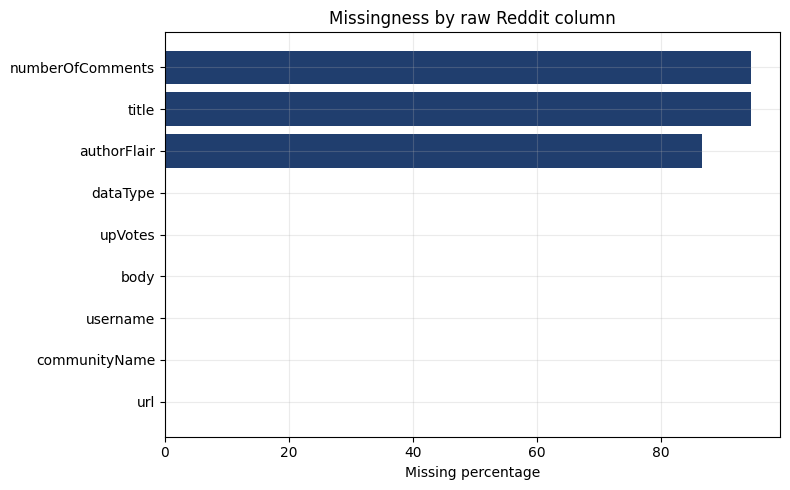

In [5]:
plt.figure(figsize=(8, 5))
plot_missing = raw_column_summary.sort_values("missing_pct", ascending=True)
plt.barh(plot_missing["column"], plot_missing["missing_pct"], color=PRIMARY)
plt.xlabel("Missing percentage")
plt.title("Missingness by raw Reddit column")
plt.tight_layout()
plt.show()


In [6]:
raw_duplicate_summary = pd.Series(
    {
        "duplicate_full_rows": int(df_raw.duplicated().sum()),
        "duplicate_urls": int(df_raw["url"].duplicated().sum()),
        "blank_all_columns_count": int(df_raw.isna().all(axis=0).sum()),
        "unique_usernames": int(df_raw["username"].nunique(dropna=True)),
        "unique_communities": int(df_raw["communityName"].nunique(dropna=True)),
    }
)

date_like_cols = [col for col in df_raw.columns if any(key in col.lower() for key in ["date", "time", "created"])]

print("Raw duplicate summary:")
display(raw_duplicate_summary.to_frame(name="value"))
print("Possible date-like columns:", date_like_cols if date_like_cols else "none found")


Raw duplicate summary:


,value
duplicate_full_rows,4
duplicate_urls,8
blank_all_columns_count,0
unique_usernames,3316
unique_communities,490


Possible date-like columns: none found


The Reddit export is simpler than the Twitter file. Duplicate URLs matter, several export columns are mostly blank, and there is no reliable timestamp field that would support the same time-series analysis used in the Twitter notebook.


## III. Cleaning the structured fields


In [7]:
df = df_raw.rename(
    columns={
        "authorFlair": "author_flair",
        "numberOfComments": "number_of_comments",
        "communityName": "community_name",
        "upVotes": "upvotes",
    }
).copy()

df["title"] = df["title"].fillna("").astype(str)
df["body"] = df["body"].fillna("").astype(str)
df["text"] = (df["title"].str.strip() + "\n" + df["body"].str.strip()).str.strip()
df["community_name"] = df["community_name"].fillna("(missing)").astype(str)
df["community_short"] = df["community_name"].str.replace(r"^r/", "", regex=True)
df["username"] = df["username"].fillna("[missing]").astype(str)
df["author_flair"] = df["author_flair"].fillna("(missing)").astype(str)
df["has_flair"] = df["author_flair"].ne("(missing)")
df["upvotes"] = pd.to_numeric(df["upvotes"], errors="coerce").fillna(0)
df["body_length"] = df["body"].str.len()
df["text_clean"] = df["text"].map(basic_clean)
df["url_host"] = (
    df["url"].fillna("").astype(str).str.extract(r"https?://([^/]+)", expand=False).fillna("(missing)")
)

combined_text = (df["title"] + " " + df["body"]).astype(str)
core_match = combined_text.str.contains(CORE_FAA_PATTERN, na=False)
aux_match = combined_text.str.contains(FAA_AUX_PATTERN, na=False)
community_match = df["community_name"].str.contains(AVIATION_COMMUNITY_PATTERN, na=False)

df["faa_relevant"] = core_match | (aux_match & community_match)

df = (
    df.sort_values(["url", "upvotes"], ascending=[True, False])
    .drop_duplicates(subset="url", keep="first")
    .reset_index(drop=True)
)

df = df[df["faa_relevant"]].copy()
df = df[df["text_clean"].str.len() >= 20].reset_index(drop=True)

print("Working Reddit subset shape:", df.shape)


Working Reddit subset shape: (769, 16)


In [8]:
clean_column_summary = summarize_columns(df)
display(clean_column_summary)

clean_subset_summary = pd.DataFrame(
    [
        ["analysis_rows", len(df)],
        ["unique_subreddits", df["community_name"].nunique()],
        ["posts", int((df["dataType"] == "post").sum())],
        ["comments", int((df["dataType"] == "comment").sum())],
        ["median_upvotes", float(df["upvotes"].median())],
        ["median_body_length", float(df["body_length"].median())],
    ],
    columns=["metric", "value"],
)
display(clean_subset_summary)


,column,dtype,missing_count,missing_pct,n_unique,zero_pct
0,number_of_comments,float64,741,96.360,17,97.140
1,url,str,0,0.000,769,NaN
2,body,str,0,0.000,754,NaN
3,text,str,0,0.000,753,NaN
4,text_clean,str,0,0.000,750,NaN
5,body_length,int64,0,0.000,641,0.000
6,username,str,0,0.000,613,NaN
7,community_name,str,0,0.000,255,NaN
8,community_short,str,0,0.000,255,NaN
9,author_flair,str,0,0.000,98,NaN


,metric,value
0,analysis_rows,769.000
1,unique_subreddits,255.000
2,posts,28.000
3,comments,741.000
4,median_upvotes,2.000
5,median_body_length,683.000


## IV. Basic EDA on the structured columns


In [9]:
print("Top communities:")
display(df["community_name"].value_counts().head(15).rename_axis("community_name").reset_index(name="rows"))
print()
print("Top authors:")
display(df["username"].value_counts().head(15).rename_axis("username").reset_index(name="rows"))
print()
print("Top flairs:")
display(df["author_flair"].value_counts().head(15).rename_axis("author_flair").reset_index(name="rows"))
print()
print("Structured summary:")
display(
    pd.DataFrame(
        {
            "upvotes": df["upvotes"].describe(),
            "body_length": df["body_length"].describe(),
        }
    ).round(2)
)


Top communities:


,community_name,rows
0,r/atc2,66
1,r/aviation,52
2,r/flying,49
3,r/ATC,37
4,r/fednews,29
5,r/interesting,23
6,r/unitedairlines,23
7,r/CatastrophicFailure,15
8,r/delta,14
9,r/aircrashinvestigation,12



Top authors:


,username,rows
0,[deleted],13
1,FunkyChickenKong,9
2,HuzzahBot,8
3,No-Constant-5854,7
4,wiredmagazine,7
5,Key_Understanding771,7
6,rFlyingTower,7
7,ITGuy7337,6
8,You_an_idiot_brah,5
9,railker,5



Top flairs:


,author_flair,rows
0,(missing),636
1,:huzbot1::huzbot2::huzbot3::huzbot4::huzbot5::huzbot6:,8
2,Airline Pilot,6
3,PPL,4
4,Spoon 🥄,3
5,Flight Attendant,3
6,ATC PPL,3
7,ATC #SayNoToKilo,3
8,Multicopters - Focus on Sub-250 g,3
9,Current Controller-Tower,2



Structured summary:


,upvotes,body_length
count,769.000,769.000
mean,14.910,"1,427.290"
std,64.460,"2,369.270"
min,-17.000,29.000
25%,1.000,344.000
50%,2.000,683.000
75%,8.000,"1,617.000"
max,"1,133.000","39,031.000"


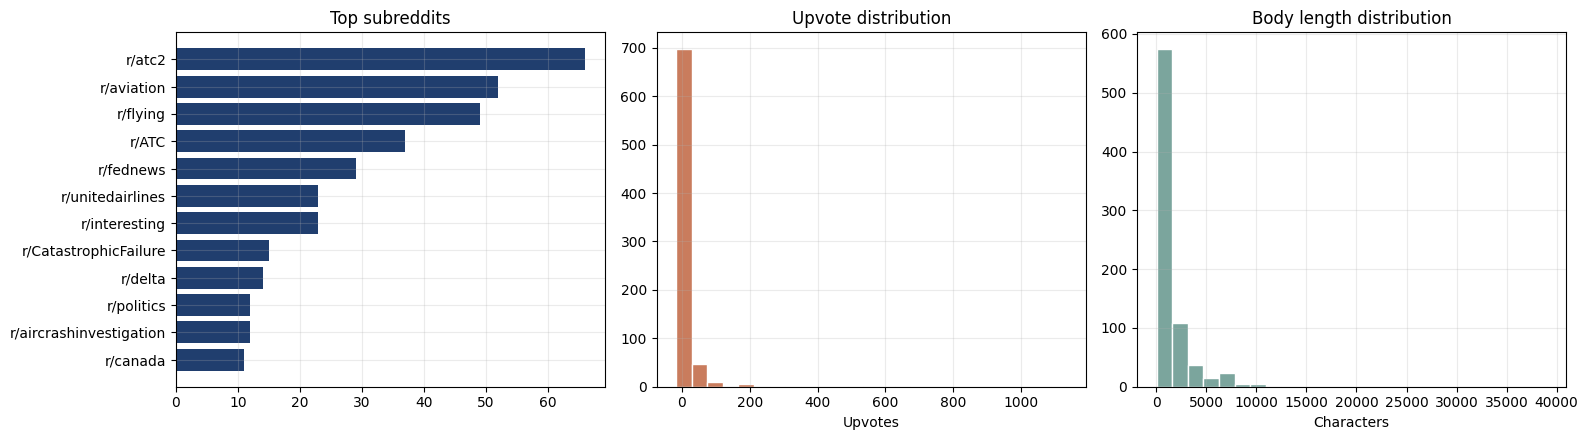

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

top_subreddits = df["community_name"].value_counts().head(12).sort_values()
axes[0].barh(top_subreddits.index, top_subreddits.values, color=PRIMARY)
axes[0].set_title("Top subreddits")

axes[1].hist(df["upvotes"], bins=25, color=SECONDARY, edgecolor="white")
axes[1].set_title("Upvote distribution")
axes[1].set_xlabel("Upvotes")

axes[2].hist(df["body_length"], bins=25, color=ACCENT, edgecolor="white")
axes[2].set_title("Body length distribution")
axes[2].set_xlabel("Characters")

plt.tight_layout()
plt.show()


In [11]:
top_rows = (
    df[["community_name", "username", "upvotes", "dataType", "body"]]
    .sort_values("upvotes", ascending=False)
    .head(10)
    .assign(body_excerpt=lambda frame: frame["body"].str.replace("\n", " ", regex=False).str.slice(0, 180))
    .drop(columns="body")
    .reset_index(drop=True)
)
top_rows


,community_name,username,upvotes,dataType,body_excerpt
0,r/aviation,blightedquark,1133,comment,"And her senseless death caused the FAA to write a new rule, so other kids wouldn’t needlessly perish in the hope of imagined glory. [H. Rept. 104-683 - CHILD PILOT SAFETY ACT](htt"
1,r/fednews,Pileopilot,660,comment,How about they pay the rest of us that have been doing the job for years that? This recruitment push does nothing to fix the horrible attrition rate between the academy and the
2,r/fednews,fortune,607,post,"On Roblox, an online gaming platform beloved by Gen Z and Gen Alpha, the site’s 151.5 million daily active users can manage and direct pixelated air traffic through an air traffic"
3,r/unitedairlines,whitert89,576,post,"I’ve never posted, but I was looking for photos of the Polaris Studio experience before my flight and couldn’t find any. Figured I’d share. A few thoughts: \- The suite is more"
4,r/CatastrophicFailure,a1b3c3d7,528,comment,"We all offered the same sympathies and condolences the last time, and prayed this wouldn't happen again but make no mistake.. this WILL happen again and MORE people will die becaus"
5,r/flying,oops_i,349,post,**TL;DR:** Salt-air corrosion in the HPC variable-geometry stator vane spindle bores of both GE CF34-3B engines jammed the VGs in an off-schedule position. Power reduction for land
6,r/nyc,marty-mcfryguy,252,comment,"The news in this headline was reported a month ago, the day after the crash. [https://www.cbsnews.com/newyork/news/air-traffic-control-deadly-laguardia-runway-crash/](https://www."
7,r/fednews,DaytonaJoe,203,comment,I've been an air traffic controller for 15 years at moderately busy facilities and without overtime I'm not making $155k.
8,r/aviation,gavriellloken,187,post,"OUR RULES ON POLITICS: 2026 IF YOU DO NOT READ THIS POST, YOU RISK BEING BANNED r/aviation is an aviation-focused subreddit. All political discussion must be directly related to"
9,r/aviation,Full_Hunt_3087,183,comment,"ATC error, plain and simple. Let the firetruck cross the runway when the plane was coming in. I've said elsewhere that I blame this entirely on the FAA budget cuts. I truly feel fo"


The structured columns show a comments-heavy dataset spread across many communities. Upvotes and text length are both right-skewed, so a small set of highly visible rows can dominate simple averages.


## V. Preprocessing the text column


In [12]:
df["n_chars_clean"] = df["text_clean"].str.len()
df["n_tokens_clean"] = df["text_clean"].str.split().str.len()

df[["text", "text_clean", "n_tokens_clean"]].sample(5, random_state=0)


,text,text_clean,n_tokens_clean
662,"The ATC that caused this was running two positions which is crazy at an airport that busy. Having another controller would have distributed the work and allowed them to have the proper focus. They are short staffed, ...",the atc that caused this was running two positions which is crazy at an airport that busy having another controller would have distributed the work and allowed them to have the proper focus they are short staffed per...,116
122,"Incorrect.\n\nATC had been understaffed since the early 2010s. It is a very specialized job with a long certification timeline, high stress, low morale, significant washout rates, hiring shortfalls, and ongoing losse...",incorrect atc had been understaffed since the early 2010s it is a very specialized job with a long certification timeline high stress low morale significant washout rates hiring shortfalls and ongoing losses faster t...,88
113,"Oh give me a break, you can’t be serious, you call the FAA workers ‘irrelevant’ but over the past three days two Southwest jets nearly collided in Nashville, and now an American Airlines plane and a Canadian aircraft...",oh give me a break you can t be serious you call the faa workers irrelevant but over the past three days two southwest jets nearly collided in nashville and now an american airlines plane and a canadian aircraft almo...,116
14,Most (if not all) countries have better regulations.\n\n\nIn the US it works the following.\n\n\n- Step 1. They don't have enough controllers to lower to amount of work hours without causing massive flight cancellati...,most if not all countries have better regulations in the us it works the following step 1 they don't have enough controllers to lower to amount of work hours without causing massive flight cancellations step 2 they d...,509
634,Well aware of what induced demand is. I also know what it isn't. If induced demand was the holy grail of transportation science then we should cut all highways down to a single lane to remove the demand. Go try it...,well aware of what induced demand is i also know what it isn't if induced demand was the holy grail of transportation science then we should cut all highways down to a single lane to remove the demand go try it you a...,156


The preprocessing demos in class use spaCy lemmatization, so we follow that same general pattern here.


In [13]:
nlp = spacy.load("en_core_web_sm")

lemmas = []
token_counts = []
for doc in nlp.pipe(df["text_clean"], batch_size=64):
    terms = []
    for token in doc:
        if token.is_space or token.is_punct:
            continue
        token_text = token.text.lower().strip()
        if not token_text or not any(ch.isalpha() for ch in token_text):
            continue
        lemma = token.lemma_.lower().strip()
        if lemma in {"", "-pron-"}:
            lemma = token_text
        terms.append(lemma)
    lemmas.append(" ".join(terms))
    token_counts.append(len(terms))

df["text_lemma"] = lemmas
df["n_tokens_lemma"] = token_counts


In [14]:
df[["text", "text_clean", "text_lemma"]].sample(5, random_state=0)


,text,text_clean,text_lemma
662,"The ATC that caused this was running two positions which is crazy at an airport that busy. Having another controller would have distributed the work and allowed them to have the proper focus. They are short staffed, ...",the atc that caused this was running two positions which is crazy at an airport that busy having another controller would have distributed the work and allowed them to have the proper focus they are short staffed per...,the atc that cause this be run two position which be crazy at an airport that busy have another controller would have distribute the work and allow they to have the proper focus they be short staff period if there be...
122,"Incorrect.\n\nATC had been understaffed since the early 2010s. It is a very specialized job with a long certification timeline, high stress, low morale, significant washout rates, hiring shortfalls, and ongoing losse...",incorrect atc had been understaffed since the early 2010s it is a very specialized job with a long certification timeline high stress low morale significant washout rates hiring shortfalls and ongoing losses faster t...,incorrect atc have be understaffed since the early 2010 it be a very specialized job with a long certification timeline high stress low morale significant washout rate hire shortfall and ongoing loss fast than the sy...
113,"Oh give me a break, you can’t be serious, you call the FAA workers ‘irrelevant’ but over the past three days two Southwest jets nearly collided in Nashville, and now an American Airlines plane and a Canadian aircraft...",oh give me a break you can t be serious you call the faa workers irrelevant but over the past three days two southwest jets nearly collided in nashville and now an american airlines plane and a canadian aircraft almo...,oh give i a break you can t be serious you call the faa worker irrelevant but over the past three day two southwest jet nearly collide in nashville and now an american airlines plane and a canadian aircraft almost ha...
14,Most (if not all) countries have better regulations.\n\n\nIn the US it works the following.\n\n\n- Step 1. They don't have enough controllers to lower to amount of work hours without causing massive flight cancellati...,most if not all countries have better regulations in the us it works the following step 1 they don't have enough controllers to lower to amount of work hours without causing massive flight cancellations step 2 they d...,most if not all country have well regulation in the us it work the follow step they do not have enough controller to lower to amount of work hour without cause massive flight cancellation step they do not give the fa...
634,Well aware of what induced demand is. I also know what it isn't. If induced demand was the holy grail of transportation science then we should cut all highways down to a single lane to remove the demand. Go try it...,well aware of what induced demand is i also know what it isn't if induced demand was the holy grail of transportation science then we should cut all highways down to a single lane to remove the demand go try it you a...,well aware of what induced demand be i also know what it be not if induced demand be the holy grail of transportation science then we should cut all highway down to a single lane to remove the demand go try it you be...


In [15]:
df[["n_tokens_clean", "n_tokens_lemma"]].describe().round(2)


,n_tokens_clean,n_tokens_lemma
count,769.000,769.000
mean,223.410,220.470
std,351.330,343.180
min,5.000,5.000
25%,57.000,56.000
50%,117.000,116.000
75%,254.000,247.000
max,"4,971.000","4,975.000"


## VI. Basic text analysis with spaCy


In [16]:
nlp_full = spacy.load("en_core_web_sm")
entity_counter = Counter()
label_counter = Counter()

for doc in nlp_full.pipe(df["text"].tolist(), batch_size=32):
    for ent in doc.ents:
        entity_counter[(ent.text.strip(), ent.label_)] += 1
        label_counter[ent.label_] += 1

top_entities = pd.DataFrame(
    [
        {"entity": entity, "label": label, "count": count}
        for (entity, label), count in entity_counter.most_common(25)
    ]
)

top_entity_labels = pd.DataFrame(
    [{"label": label, "count": count} for label, count in label_counter.most_common()]
)

display(top_entities.head(15))
display(top_entity_labels)


,entity,label,count
0,FAA,ORG,1011
1,ATC,ORG,217
2,US,GPE,187
3,one,CARDINAL,139
4,first,ORDINAL,136
5,Trump,ORG,101
6,two,CARDINAL,100
7,2,CARDINAL,81
8,AI,GPE,80
9,Trump,PERSON,79


,label,count
0,ORG,4541
1,CARDINAL,1803
2,DATE,1709
3,PERSON,1073
4,GPE,1041
5,NORP,344
6,MONEY,326
7,PERCENT,272
8,ORDINAL,267
9,TIME,225


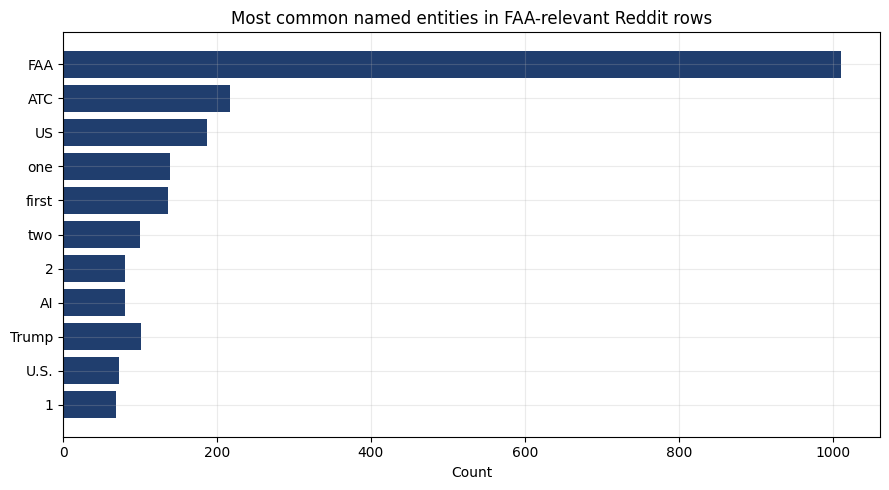

In [17]:
plot_entities = top_entities.head(12).iloc[::-1]
plt.figure(figsize=(9, 5))
plt.barh(plot_entities["entity"], plot_entities["count"], color=PRIMARY)
plt.xlabel("Count")
plt.title("Most common named entities in FAA-relevant Reddit rows")
plt.tight_layout()
plt.show()


## VII. N-grams


In [18]:
top_unigrams = get_top_ngrams(df["text_clean"], ngram_range=(1, 1), min_df=5, top_n=20)
top_bigrams = get_top_ngrams(df["text_clean"], ngram_range=(2, 2), min_df=4, top_n=20)
top_trigrams = get_top_ngrams(df["text_clean"], ngram_range=(3, 3), min_df=3, top_n=20)

display(top_unigrams.head(10))
display(top_bigrams.head(10))
display(top_trigrams.head(10))


,ngram,count
0,safety,556
1,don,333
2,trump,281
3,staffing,277
4,federal,266
5,administration,248
6,new,232
7,years,231
8,government,215
9,aircraft,196


,ngram,count
0,federal administration,77
1,trump administration,65
2,government shutdown,40
3,department transportation,36
4,budget cuts,36
5,don think,35
6,white house,28
7,executive order,28
8,long term,27
9,diversity inclusion,27


,ngram,count
0,diversity inclusion hiring,27
1,initiative diversity inclusion,18
2,inclusion hiring plan,18
3,restoring highest standards,18
4,article federal administration,11
5,signed executive order,10
6,disability dwarfism qualify,9
7,ll point various,9
8,000 run right,9
9,long crash signed,9


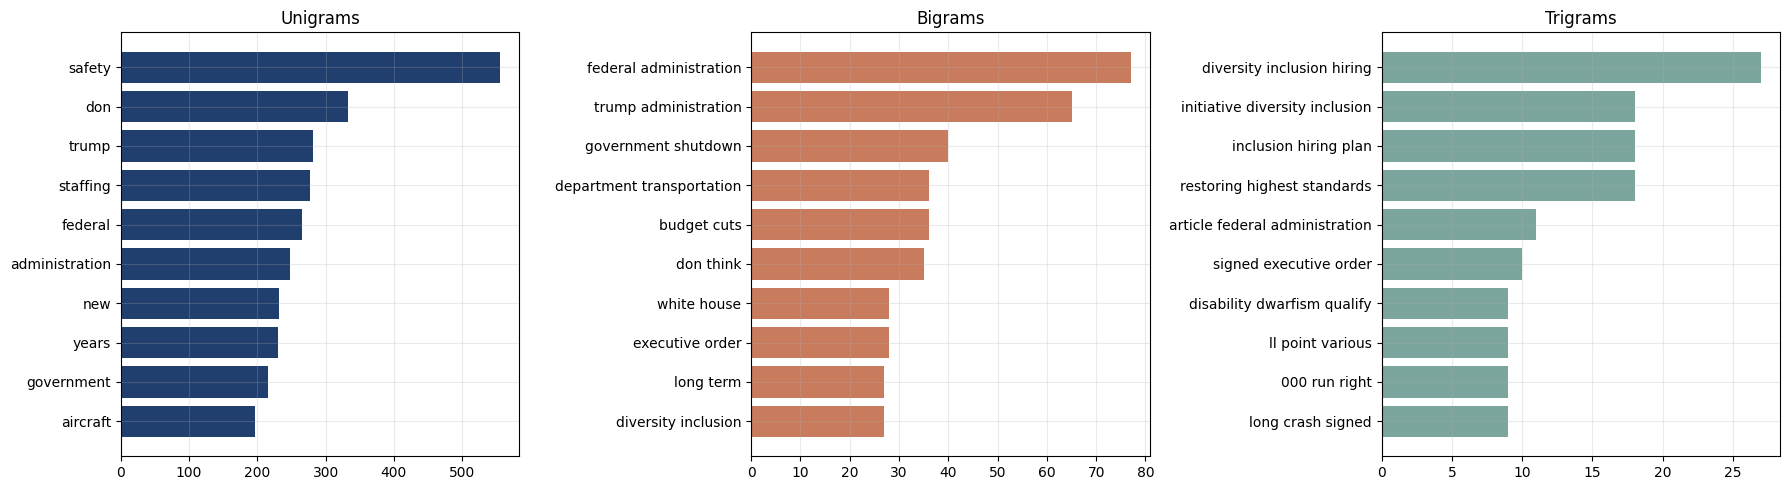

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(top_unigrams.head(10).iloc[::-1]["ngram"], top_unigrams.head(10).iloc[::-1]["count"], color=PRIMARY)
axes[0].set_title("Unigrams")

axes[1].barh(top_bigrams.head(10).iloc[::-1]["ngram"], top_bigrams.head(10).iloc[::-1]["count"], color=SECONDARY)
axes[1].set_title("Bigrams")

axes[2].barh(top_trigrams.head(10).iloc[::-1]["ngram"], top_trigrams.head(10).iloc[::-1]["count"], color=ACCENT)
axes[2].set_title("Trigrams")

plt.tight_layout()
plt.show()


## VIII. Co-occurrence analysis


In [20]:
df["keyword_labels"] = df["text_clean"].map(assign_keyword_labels)
df["plot_theme"] = df["keyword_labels"].map(choose_theme)

keyword_group_reference = pd.DataFrame(
    [{"keyword_group": key, "example_terms": ", ".join(values[:6])} for key, values in KEYWORD_GROUPS.items()]
)
display(keyword_group_reference)

keyword_labels = list(KEYWORD_GROUPS.keys())
label_sets = df["keyword_labels"].map(set)

co_occurrence_rows = []
for left in keyword_labels:
    for right in keyword_labels:
        left_mask = label_sets.map(lambda values: left in values)
        right_mask = label_sets.map(lambda values: right in values)
        joint_probability = float((left_mask & right_mask).mean())
        left_probability = float(left_mask.mean())
        right_probability = float(right_mask.mean())
        pmi = math.log2((joint_probability + 1e-6) / (left_probability * right_probability + 1e-6))
        co_occurrence_rows.append(
            {
                "keyword_1": left,
                "keyword_2": right,
                "joint_probability": joint_probability,
                "keyword_1_probability": left_probability,
                "keyword_2_probability": right_probability,
                "pmi": pmi,
            }
        )

pmi_df = pd.DataFrame(co_occurrence_rows)
pmi_pairs = (
    pmi_df[pmi_df["keyword_1"] < pmi_df["keyword_2"]]
    .sort_values(["pmi", "joint_probability"], ascending=[False, False])
    .reset_index(drop=True)
)

pmi_pairs.head(10)


,keyword_group,example_terms
0,staffing,"staffing, understaffed, shortage, shortages, short staffed, controller shortage"
1,recruitment,"hire, hiring, recruit, recruitment, academy, trainee"
2,safety_oversight,"safety, oversight, investigation, ntsb, reform, risk"
3,operations,"delay, delays, cancel, ground stop, ground delay, queue"
4,incident,"crash, collision, runway, laguardia, lga, dca"
5,working_conditions,"fatigue, overtime, pay, retire, retirement, shift"


,keyword_1,keyword_2,joint_probability,keyword_1_probability,keyword_2_probability,pmi
0,recruitment,working_conditions,0.105,0.199,0.304,0.799
1,recruitment,staffing,0.108,0.199,0.322,0.750
2,incident,operations,0.140,0.254,0.371,0.580
3,operations,recruitment,0.108,0.371,0.199,0.550
4,operations,staffing,0.170,0.371,0.322,0.511
5,staffing,working_conditions,0.127,0.322,0.304,0.377
6,incident,safety_oversight,0.178,0.254,0.545,0.367
7,operations,working_conditions,0.143,0.371,0.304,0.343
8,incident,recruitment,0.060,0.254,0.199,0.246
9,operations,safety_oversight,0.228,0.371,0.545,0.172


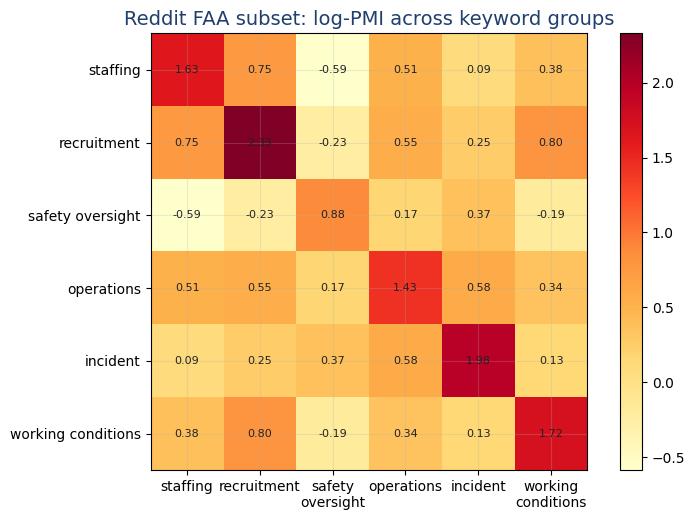

In [21]:
heatmap = pmi_df.pivot(index="keyword_1", columns="keyword_2", values="pmi").reindex(index=keyword_labels, columns=keyword_labels)

plt.figure(figsize=(8.8, 5.3))
image = plt.imshow(heatmap, cmap="YlOrRd")
plt.xticks(range(len(keyword_labels)), [name.replace("_", "\n") for name in keyword_labels], fontsize=10)
plt.yticks(range(len(keyword_labels)), [name.replace("_", " ") for name in keyword_labels], fontsize=10)
plt.title("Reddit FAA subset: log-PMI across keyword groups", fontsize=14, color=PRIMARY)
for r in range(len(keyword_labels)):
    for c in range(len(keyword_labels)):
        plt.text(c, r, f"{heatmap.iloc[r, c]:.2f}", ha="center", va="center", fontsize=8, color="#222222")
plt.colorbar(image, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


The PMI results line up well with the Twitter analysis. Staffing and operations show up broadly, but the strongest pairings are narrower combinations related to recruitment and working conditions.


## IX. TF-IDF representation


In [22]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=3,
    stop_words=CUSTOM_STOP_WORDS,
    max_features=1800,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df["text_lemma"])
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()

nonzero = tfidf_matrix.nnz
total = tfidf_matrix.shape[0] * tfidf_matrix.shape[1]
tfidf_summary = pd.DataFrame(
    [
        ["rows", tfidf_matrix.shape[0]],
        ["columns", tfidf_matrix.shape[1]],
        ["nonzero entries", nonzero],
        ["density", round(nonzero / total, 6)],
    ],
    columns=["metric", "value"],
)
display(tfidf_summary)


,metric,value
0,rows,769.000
1,columns,"1,800.000"
2,nonzero entries,"39,317.000"
3,density,0.028


## X. Linear dimensionality reduction


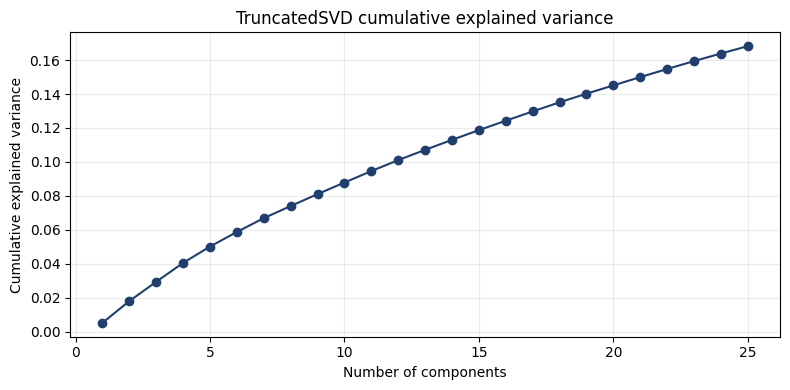

In [23]:
svd_components = min(25, tfidf_matrix.shape[0] - 1, tfidf_matrix.shape[1] - 1)
svd = TruncatedSVD(n_components=svd_components, random_state=0)
svd_embeddings = svd.fit_transform(tfidf_matrix)

explained_variance = pd.DataFrame(
    {
        "component": np.arange(1, svd_components + 1),
        "explained_variance_ratio": svd.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(svd.explained_variance_ratio_),
    }
)

plt.figure(figsize=(8, 4))
plt.plot(
    explained_variance["component"],
    explained_variance["cumulative_explained_variance"],
    marker="o",
    color=PRIMARY,
)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("TruncatedSVD cumulative explained variance")
plt.tight_layout()
plt.show()


As is common for text data, no small number of linear components explains most of the variation. Even so, the first several components still capture useful thematic structure for visualization and clustering.


,component,top_terms
0,Component 1,"safety, trump, staffing, cut, pay, administration, job, pilot"
1,Component 2,"fly, pilot, trump, drone, aircraft, administration, cut, hire"
2,Component 3,"pay, staffing, diversity, facility, disability, administration, don, staff"
3,Component 4,"trump, cut, diversity, disability, employee, budget, administration, job"
4,Component 5,"budget, cut, staffing, don, staff, money, hire, administration"
5,Component 6,"drone, runway, budget, cut, fly, stop, truck, collision"


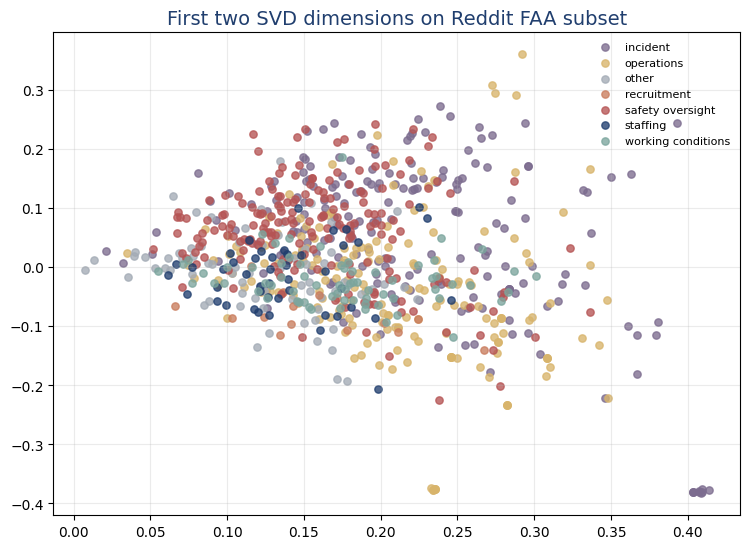

In [24]:
component_term_summary = pd.DataFrame(
    [
        {"component": f"Component {idx + 1}", "top_terms": ", ".join(get_top_component_terms(svd, tfidf_vocab, idx, top_n=8))}
        for idx in range(min(6, svd_components))
    ]
)
display(component_term_summary)

fig, ax = plt.subplots(figsize=(7.6, 5.6))
for label in sorted(df["plot_theme"].unique()):
    mask = df["plot_theme"] == label
    ax.scatter(
        svd_embeddings[mask, 0],
        svd_embeddings[mask, 1],
        s=28,
        alpha=0.78,
        color=THEME_COLORS.get(label, "#999999"),
        label=label.replace("_", " "),
    )
ax.set_title("First two SVD dimensions on Reddit FAA subset", fontsize=14, color=PRIMARY)
ax.legend(loc="upper right", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


The first two linear dimensions already separate some recurring themes, although the groups are not completely clean. That is still useful because later methods can build on these compressed text dimensions.


## XI. Manifold learning


In [25]:
manifold_input = StandardScaler().fit_transform(svd_embeddings[:, : min(25, svd_embeddings.shape[1])])
sample_size = min(600, len(df))
rng = np.random.default_rng(0)
sample_idx = np.sort(rng.choice(len(df), size=sample_size, replace=False)) if sample_size < len(df) else np.arange(len(df))

sample_input = manifold_input[sample_idx]
sample_labels = df.iloc[sample_idx]["plot_theme"].reset_index(drop=True)

manifold_summary = pd.DataFrame(
    [
        ["tfidf_rows", tfidf_matrix.shape[0]],
        ["tfidf_columns", tfidf_matrix.shape[1]],
        ["svd_dimensions_used", min(25, svd_embeddings.shape[1])],
        ["manifold_sample_size", sample_size],
    ],
    columns=["metric", "value"],
)
display(manifold_summary)

isomap = Isomap(n_neighbors=min(15, sample_size - 1), n_components=2)
mds = MDS(n_components=2, random_state=0, n_init=1, max_iter=300)
tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, sample_size // 10)),
    learning_rate="auto",
    init="pca",
    random_state=0,
    max_iter=1000,
)

isomap_embedding = isomap.fit_transform(sample_input)
mds_embedding = mds.fit_transform(sample_input)
tsne_embedding = tsne.fit_transform(sample_input)


,metric,value
0,tfidf_rows,769
1,tfidf_columns,1800
2,svd_dimensions_used,25
3,manifold_sample_size,600


The UMAP code is omitted here for the same practical reason as in the Twitter notebook: the local workflow was already well served by Isomap, MDS, and t-SNE, and the added complexity was not necessary for the analysis.


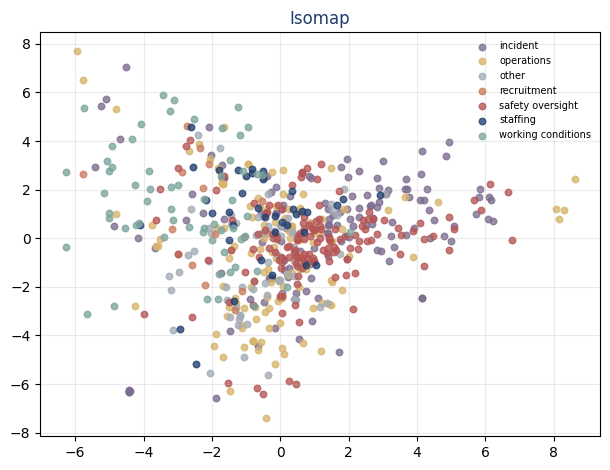

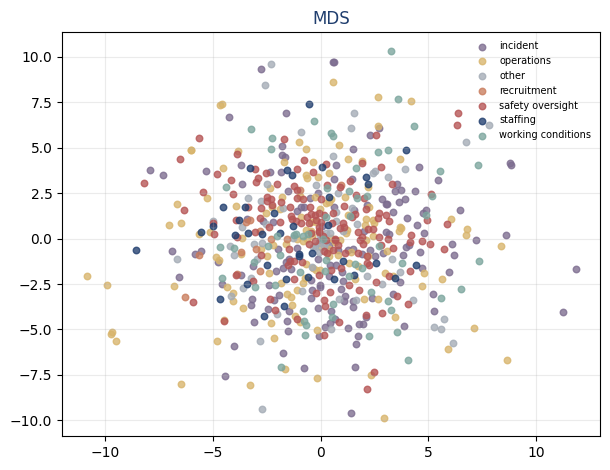

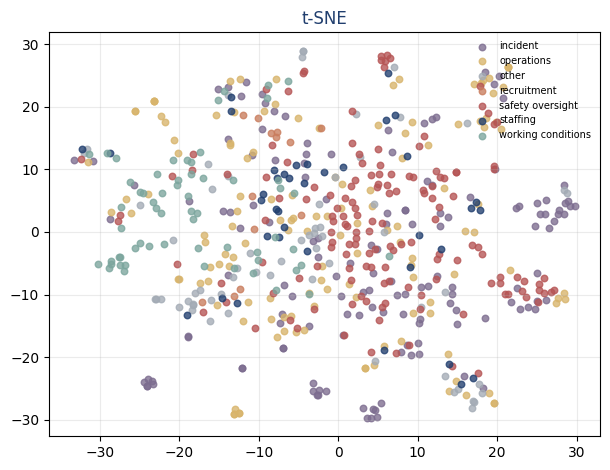

In [26]:
plot_embedding(isomap_embedding, "Isomap", sample_labels)
plot_embedding(mds_embedding, "MDS", sample_labels)
plot_embedding(tsne_embedding, "t-SNE", sample_labels)


Across the manifold methods, Isomap provides a readable global structure, MDS is more diffuse, and t-SNE gives the clearest local groupings. That pattern is very similar to the Twitter notebook.


## XII. Clustering


,k,inertia,silhouette,calinski_harabasz
0,2,116.874,0.493,52.732
1,3,110.340,0.062,50.573
2,4,105.157,0.096,47.898
3,5,100.790,0.103,45.707
4,6,94.958,0.099,48.134
5,7,91.876,0.100,45.662
6,8,86.851,0.107,47.639


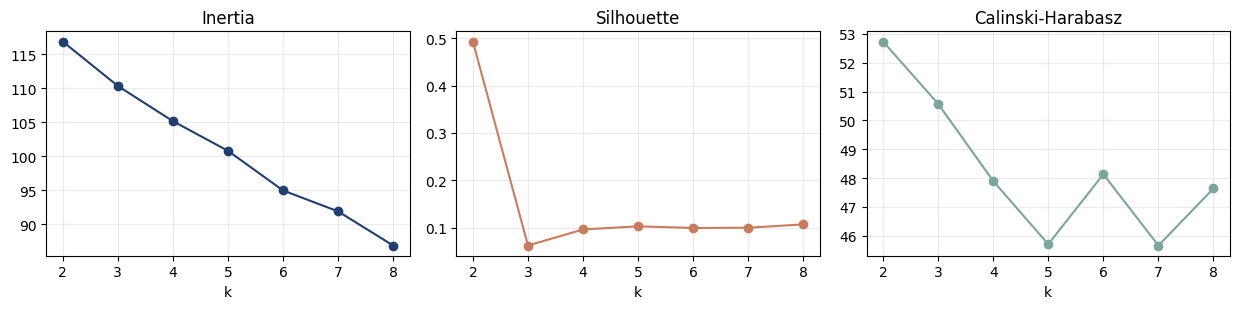

In [27]:
cluster_input = svd_embeddings[:, : min(25, svd_embeddings.shape[1])]
k_values = range(2, 9)
kmeans_metric_rows = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=0, n_init=20)
    labels = model.fit_predict(cluster_input)
    kmeans_metric_rows.append(
        {
            "k": k,
            "inertia": float(model.inertia_),
            "silhouette": float(silhouette_score(cluster_input, labels, sample_size=min(len(df), 600), random_state=0)),
            "calinski_harabasz": float(calinski_harabasz_score(cluster_input, labels)),
        }
    )

kmeans_metrics = pd.DataFrame(kmeans_metric_rows)
display(kmeans_metrics)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
axes[0].plot(kmeans_metrics["k"], kmeans_metrics["inertia"], marker="o", color=PRIMARY)
axes[0].set_title("Inertia")
axes[1].plot(kmeans_metrics["k"], kmeans_metrics["silhouette"], marker="o", color=SECONDARY)
axes[1].set_title("Silhouette")
axes[2].plot(kmeans_metrics["k"], kmeans_metrics["calinski_harabasz"], marker="o", color=ACCENT)
axes[2].set_title("Calinski-Harabasz")
for ax in axes:
    ax.set_xlabel("k")
plt.tight_layout()
plt.show()


In `sklearn`, the `inertia` attribute is the within-cluster residual sum of squares, so the RSS and inertia ideas from class carry over directly. We use these metrics as rough guides rather than strict rules.


,cluster,share_pct,top_terms
2,2,50.800,"safety, fly, pilot, aircraft, drone"
1,1,24.300,"staffing, pay, staff, facility, hire"
0,0,11.800,"trump, administration, employee, federal, safety"
3,3,11.100,"budget, cut, money, pay, trump"
4,4,1.200,"diversity, disability, severe, obama, office"
5,5,0.800,"administration, reportedly, dig, washout, exempt"


plot_theme,incident,operations,other,recruitment,safety_oversight,staffing,working_conditions
kmeans_cluster,,,,,,,
0,0.240,0.560,0.040,0.010,0.130,0.010,0.000
1,0.170,0.210,0.050,0.060,0.070,0.130,0.300
2,0.320,0.160,0.080,0.000,0.390,0.040,0.010
3,0.070,0.210,0.330,0.040,0.160,0.070,0.120
4,1.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,1.000,0.000,0.000,0.000,0.000,0.000


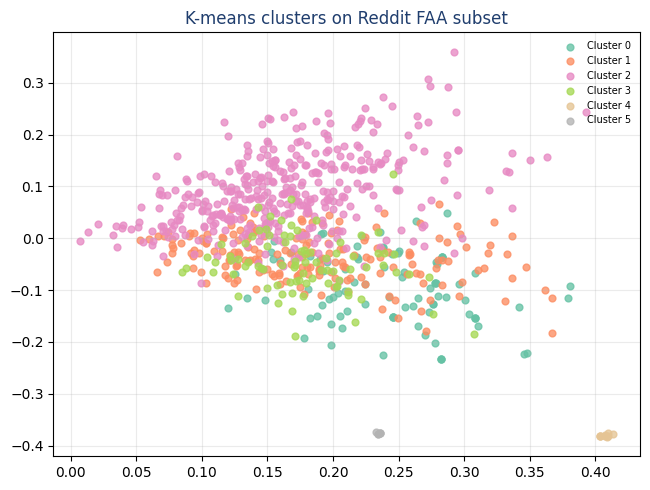

In [28]:
chosen_k = 6
kmeans_model = KMeans(n_clusters=chosen_k, random_state=0, n_init=20)
df["kmeans_cluster"] = kmeans_model.fit_predict(cluster_input)


def get_top_cluster_terms(cluster_id, matrix, labels, vocab, top_n=10):
    mask = labels == cluster_id
    mean_weights = np.asarray(matrix[mask].mean(axis=0)).ravel()
    order = mean_weights.argsort()[::-1][:top_n]
    return list(vocab[order])


cluster_term_summary = pd.DataFrame(
    [
        {
            "cluster": cluster_id,
            "share_pct": round((df["kmeans_cluster"] == cluster_id).mean() * 100, 1),
            "top_terms": ", ".join(get_top_cluster_terms(cluster_id, tfidf_matrix, df["kmeans_cluster"].to_numpy(), tfidf_vocab, top_n=8)[:5]),
        }
        for cluster_id in sorted(df["kmeans_cluster"].unique())
    ]
).sort_values("share_pct", ascending=False)

cluster_theme_summary = pd.crosstab(df["kmeans_cluster"], df["plot_theme"], normalize="index").round(2)

display(cluster_term_summary)
display(cluster_theme_summary)

fig, ax = plt.subplots(figsize=(6.6, 5.0))
colors = plt.cm.Set2(np.linspace(0, 1, chosen_k))
for cluster_id, color in zip(sorted(df["kmeans_cluster"].unique()), colors):
    mask = df["kmeans_cluster"] == cluster_id
    ax.scatter(svd_embeddings[mask, 0], svd_embeddings[mask, 1], s=24, alpha=0.78, color=color, label=f"Cluster {cluster_id}")
ax.set_title("K-means clusters on Reddit FAA subset", fontsize=12, color=PRIMARY)
ax.legend(loc="upper right", fontsize=7, frameon=False)
plt.tight_layout()
plt.show()


The `k`-means solution gives the clearest broad partition of the Reddit corpus. One large cluster centers on safety and flying, another on staffing and pay, and smaller clusters isolate runway incidents and policy spillovers.


To complement `k`-means, we also try density-based clustering. As in the Twitter notebook, it helps to work with a lower-dimensional standardized representation.


,metric,value
0,clusters,4.000
1,noise_pct,60.300


plot_theme,incident,operations,other,recruitment,safety_oversight,staffing,working_conditions
dbscan_cluster,,,,,,,
-1,0.290,0.290,0.070,0.030,0.180,0.060,0.090
0,0.180,0.150,0.120,0.010,0.380,0.060,0.090
1,1.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.120,0.620,0.000,0.250,0.000,0.000
3,0.000,0.000,0.440,0.110,0.000,0.110,0.330


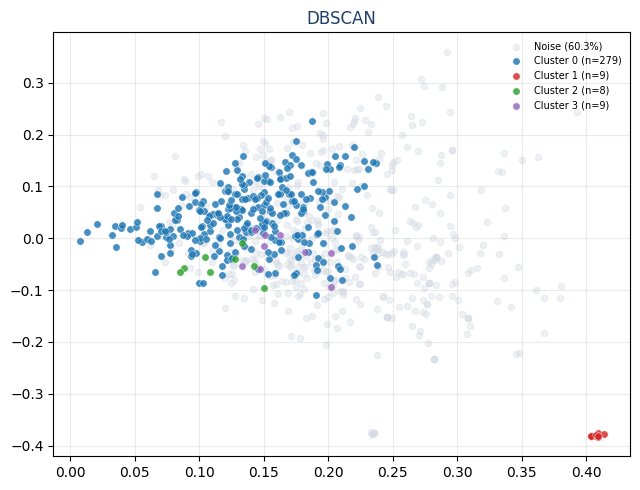

In [29]:
density_cluster_input = StandardScaler().fit_transform(svd_embeddings[:, : min(10, svd_embeddings.shape[1])])
dbscan = DBSCAN(eps=1.15, min_samples=8)
dbscan_labels = dbscan.fit_predict(density_cluster_input)

dbscan_summary = pd.DataFrame(
    [
        ["clusters", int(len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))],
        ["noise_pct", round(float((dbscan_labels == -1).mean() * 100), 1)],
    ],
    columns=["metric", "value"],
)
dbscan_theme_summary = pd.crosstab(pd.Series(dbscan_labels, name="dbscan_cluster"), df["plot_theme"], normalize="index").round(2)

display(dbscan_summary)
display(dbscan_theme_summary)
plot_density_clusters(svd_embeddings[:, :2], dbscan_labels, "DBSCAN")


`DBSCAN` behaves differently from `k`-means. Instead of partitioning every row into a small number of broad groups, it identifies one large mixed core plus a handful of denser pockets and leaves a substantial share as noise.


We now try `HDBSCAN`, which can adapt more flexibly to uneven cluster densities.


,metric,value
0,clusters,2.000
1,noise_pct,83.700


plot_theme,incident,operations,other,recruitment,safety_oversight,staffing,working_conditions
hdbscan_cluster,,,,,,,
-1,0.270,0.250,0.100,0.020,0.190,0.060,0.110
0,0.170,0.110,0.060,0.000,0.630,0.030,0.000
1,0.160,0.160,0.260,0.110,0.050,0.260,0.000


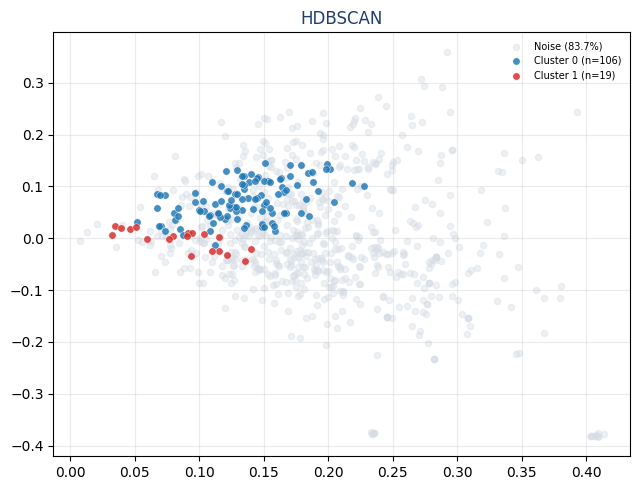

In [30]:
hdbscan_input = StandardScaler().fit_transform(svd_embeddings[:, : min(6, svd_embeddings.shape[1])])
hdbscan_model = HDBSCAN(min_cluster_size=12, min_samples=6, cluster_selection_method="leaf")
hdbscan_labels = hdbscan_model.fit_predict(hdbscan_input)

hdbscan_summary = pd.DataFrame(
    [
        ["clusters", int(len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0))],
        ["noise_pct", round(float((hdbscan_labels == -1).mean() * 100), 1)],
    ],
    columns=["metric", "value"],
)
hdbscan_theme_summary = pd.crosstab(pd.Series(hdbscan_labels, name="hdbscan_cluster"), df["plot_theme"], normalize="index").round(2)

display(hdbscan_summary)
display(hdbscan_theme_summary)
plot_density_clusters(svd_embeddings[:, :2], hdbscan_labels, "HDBSCAN")


`HDBSCAN` is the most conservative method here. It labels a meaningful share of Reddit rows as noise, but the clusters it does keep are relatively dense and coherent.


## XIII. Topic modeling with LDA


,k,perplexity,coherence,unique_words,coherence_rank,unique_rank,rank_sum
0,2,839.077,-260.034,11.000,1.000,1.000,2.000
1,3,824.379,-310.088,10.667,5.000,2.000,7.000
2,4,818.073,-339.935,8.750,6.000,3.000,9.000
3,5,800.135,-290.063,8.000,2.000,4.000,6.000
4,6,792.371,-305.038,7.667,4.000,5.000,9.000
5,7,772.409,-290.225,7.143,3.000,6.000,9.000


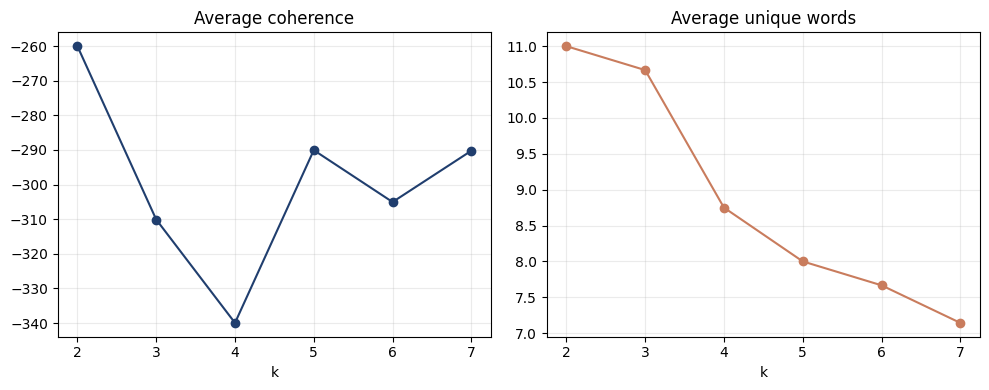

In [31]:
topic_vectorizer = CountVectorizer(
    stop_words=CUSTOM_STOP_WORDS,
    min_df=3,
    max_df=0.8,
    max_features=1200,
)
tfidf_topic = topic_vectorizer.fit_transform(df["text_lemma"])
topic_vocab = topic_vectorizer.get_feature_names_out()
vocab_lookup = {word: idx for idx, word in enumerate(topic_vocab)}

topic_k_values = range(2, 8)
topic_metric_rows = []
for k in topic_k_values:
    lda_candidate = LatentDirichletAllocation(n_components=k, random_state=0, learning_method="batch")
    lda_candidate.fit(tfidf_topic)
    topic_metric_rows.append(
        {
            "k": k,
            "perplexity": float(lda_candidate.perplexity(tfidf_topic)),
            "coherence": compute_average_coherence(lda_candidate.components_, topic_vocab, tfidf_topic, vocab_lookup),
            "unique_words": compute_average_num_unique_words(lda_candidate.components_, topic_vocab),
        }
    )

topic_metric_frame = pd.DataFrame(topic_metric_rows)
topic_metric_frame["coherence_rank"] = topic_metric_frame["coherence"].rank(ascending=False, method="min")
topic_metric_frame["unique_rank"] = topic_metric_frame["unique_words"].rank(ascending=False, method="min")
topic_metric_frame["rank_sum"] = topic_metric_frame["coherence_rank"] + topic_metric_frame["unique_rank"]

display(topic_metric_frame)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(topic_metric_frame["k"], topic_metric_frame["coherence"], marker="o", color=PRIMARY)
axes[0].set_title("Average coherence")
axes[0].set_xlabel("k")
axes[1].plot(topic_metric_frame["k"], topic_metric_frame["unique_words"], marker="o", color=SECONDARY)
axes[1].set_title("Average unique words")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()


As in the topic-modeling demo, the metric values are only part of the story. A smaller `k` can look slightly better on raw coherence while still collapsing distinct themes together. Here, `k = 4` gives the clearest presentation-ready split.


,topic,share_pct
0,0,18.100
1,1,55.000
2,2,23.700
3,3,3.300


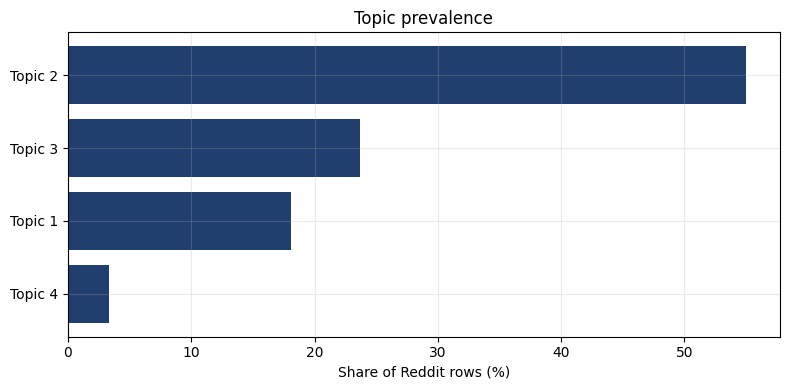

In [32]:
chosen_num_topics = 4
lda_topic_model = LatentDirichletAllocation(n_components=chosen_num_topics, random_state=0, learning_method="batch")
lda_topic_model.fit(tfidf_topic)

doc_topic_matrix = lda_topic_model.transform(tfidf_topic)
df["dominant_topic"] = doc_topic_matrix.argmax(axis=1)
df["dominant_topic_probability"] = doc_topic_matrix.max(axis=1)

topic_words = [get_top_words(row, topic_vocab, 8) for row in lda_topic_model.components_]
topic_prevalence_summary = (
    df["dominant_topic"].value_counts(normalize=True).sort_index().mul(100).round(1).rename_axis("topic").reset_index(name="share_pct")
)

display(topic_prevalence_summary)

plt.figure(figsize=(8, 4))
plot_topic_prevalence = topic_prevalence_summary.sort_values("share_pct", ascending=True)
plt.barh(
    [f"Topic {idx + 1}" for idx in plot_topic_prevalence["topic"]],
    plot_topic_prevalence["share_pct"],
    color=PRIMARY,
)
plt.xlabel("Share of Reddit rows (%)")
plt.title("Topic prevalence")
plt.tight_layout()
plt.show()


In [33]:
topic_theme_matrix = (
    pd.crosstab(df["dominant_topic"], df["plot_theme"], normalize="index")
    .round(2)
)
topic_label_lookup = make_topic_labels(topic_words, topic_theme_matrix)

display(
    pd.DataFrame(
        [
            {
                "topic": idx,
                "topic_label": topic_label_lookup[idx],
                "top_words": ", ".join(words),
            }
            for idx, words in enumerate(topic_words)
        ]
    )
)

topic_theme_summary = topic_theme_matrix.reset_index(names="topic")
topic_theme_summary.insert(1, "topic_label", topic_theme_summary["topic"].map(topic_label_lookup))
topic_theme_summary.columns.name = "plot_theme"
display(topic_theme_summary)

representative_rows = (
    df[["community_name", "username", "upvotes", "body", "dominant_topic", "dominant_topic_probability"]]
    .sort_values(["dominant_topic", "dominant_topic_probability", "upvotes"], ascending=[True, False, False])
    .groupby("dominant_topic")
    .head(3)
    .assign(
        topic_label=lambda frame: frame["dominant_topic"].map(topic_label_lookup),
        body_excerpt=lambda frame: frame["body"].str.replace("\n", " ", regex=False).str.slice(0, 200),
    )
    .drop(columns="body")
    .loc[
        :,
        [
            "topic_label",
            "dominant_topic",
            "dominant_topic_probability",
            "community_name",
            "username",
            "upvotes",
            "body_excerpt",
        ],
    ]
    .reset_index(drop=True)
)

representative_rows


,topic,topic_label,top_words
0,0,operations / safety oversight / government,"government, safety, federal, security, use, shutdown, new, report"
1,1,incident / safety oversight / fly,"fly, pilot, need, safety, plane, aircraft, pay, drone"
2,2,operations / safety oversight / trump,"trump, cut, safety, budget, administration, federal, employee, doge"
3,3,incident / safety oversight / ai,"ai, high, software, diversity, market, disability, job, run"


plot_theme,topic,topic_label,incident,operations,other,recruitment,safety_oversight,staffing,working_conditions
0,0,operations / safety oversight / government,0.160,0.370,0.090,0.010,0.270,0.040,0.050
1,1,incident / safety oversight / fly,0.290,0.150,0.090,0.020,0.240,0.070,0.140
2,2,operations / safety oversight / trump,0.190,0.320,0.130,0.020,0.250,0.060,0.030
3,3,incident / safety oversight / ai,0.560,0.080,0.080,0.000,0.280,0.000,0.000


,topic_label,dominant_topic,dominant_topic_probability,community_name,username,upvotes,body_excerpt
0,operations / safety oversight / government,0,0.998,r/flying,rFlyingTower,2,"This is a copy of the original post body for posterity: --- From my perspective as a former student, the quality of training had noticeably declined, and much of that seemed tied to internal cultur"
1,operations / safety oversight / government,0,0.998,r/flying,rFlyingTower,-4,"This is a copy of the original post body for posterity: --- Copying an email: (Also, apologies this is last minute) Dear Journeys Patron Once in a while, there is an opportunity to make a dif"
2,operations / safety oversight / government,0,0.998,r/flying,Mechanical_villain69,0,"From my perspective as a former student, the quality of training had noticeably declined, and much of that seemed tied to internal culture especially the relationships between instructors and check in"
3,incident / safety oversight / fly,1,0.999,r/HFY,FACwrites,3,The sound of a door slamming shut tore me out of my dreams. My heart pounded as I leapt to my feet. My hazy vision settled on Ethan’s mom trudging in with two gallons of milk from the morning delivery
4,incident / safety oversight / fly,1,0.996,r/fearofflying,GrndPointNiner,4,I think you probably think of ATC as the only thing preventing collisions but they're actually closer to the last line of defence. About 98% of airports in the US don't have any air traffic control a
5,incident / safety oversight / fly,1,0.995,r/VATSIM,CharlieFoxtrot000,16,"There are a lot of rules, lotsa little gotchas for VFR and it’s very dependent on where you’re doing it. But comparing it to IFR, in the US, the big-picture differences (without listing every single"
6,operations / safety oversight / trump,2,0.998,r/AskReddit,SonicReducer2112,0,"1. Immigration and Border Security • Signed the Laken Riley Act into law (January 29, 2025): Requires ICE to detain illegal immigrants accused of theft or assaulting police officers, named after a Ge"
7,operations / safety oversight / trump,2,0.998,r/NoFilterNews,SonicReducer2112,-5,"1.\t⁠Immigration and Border Security • Signed the Laken Riley Act into law (January 29, 2025): Requires ICE to detain illegal immigrants accused of theft or assaulting police officers, named after a G"
8,operations / safety oversight / trump,2,0.998,r/AskReddit,Beguiled_Potato,2,"1ST 6-MONTHS OF TRUMP 2.0 🏛️Cabinet Picks * Elon Musk DOGE - gets golden key, a black eye, &amp;💔 * SecDef Hegseth - Signal Gate 1 &amp; 2 * DNI Gabbard - lies under oath * NSA Waltz → UN Ambass"
9,incident / safety oversight / ai,3,1.000,r/ai_trading,tickeron_community,0,# Key Takeaways * The iShares Expanded Tech-Software Sector ETF ( [IGV](https://tickeron.com/ticker/IGV/)) dropped 30% in Q1 2026 — its worst quarterly decline since Q4 2008 — driven entirely by sent


The LDA results line up well with the earlier sections. Staffing and pay remain the biggest theme, safety and flying form a near-equal second topic, and a smaller federal-cut topic captures the policy spillover that also appeared in clustering.


## XIV. Sentiment and emotion with a pretrained transformer


The goal here is not to treat the model output as ground truth. Instead, we use it as another descriptive layer that may help us see whether Reddit discussions skew more toward fear, anger, sadness, or neutral commentary in different theme areas.


#### 14.1. Load pretrained emotion model


In [34]:
emotion_model_name = "j-hartmann/emotion-english-distilroberta-base"
emotion_classifier = pipeline(
    "text-classification",
    model=emotion_model_name,
    top_k=None,
    truncation=True,
    max_length=256,
    batch_size=16,
)

print("Emotion model loaded:", emotion_model_name)


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 29630.76it/s]


RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Emotion model loaded: j-hartmann/emotion-english-distilroberta-base


#### 14.2. Test the model


In [35]:
print("TESTING EMOTION CLASSIFIER")
test_texts = df["text"].head(3).tolist()
test_outputs = emotion_classifier(test_texts)

test_results = []
for text, output in zip(test_texts, test_outputs):
    scores = {row["label"].lower(): row["score"] for row in output}
    test_results.append(
        {
            "text_excerpt": text.replace("\n", " ")[:160],
            "top_emotion": max(scores, key=scores.get),
            "confidence": round(max(scores.values()), 3),
        }
    )
pd.DataFrame(test_results)


TESTING EMOTION CLASSIFIER


,text_excerpt,top_emotion,confidence
0,"Many things - this is just my perspective but the ones I hear the most often are: their antiquated view of mental healthcare, usage of obsolete methods and tech",neutral,0.828
1,"I do believe ""Regulatory Policy"" for safety issues, flight paths, vertiports, charging stations are all factors. Keep in mind, a distinct difference in target",neutral,0.835
2,"🚨$ACHR x $PLTR: Archer filed two new trademarks: ""GUARDIAN"" and ""ARCHER GUARDIAN""🚨 On March 27, 2026, Archer Aviation filed for **GUARDIAN** and **ARCHER GUARDI",neutral,0.837


#### 14.3. Batch classify all Reddit rows


In [36]:
print("CLASSIFYING ALL REDDIT ROWS")
emotion_outputs = emotion_classifier(df["text"].tolist())
len(emotion_outputs)


CLASSIFYING ALL REDDIT ROWS


769

#### 14.4. Extract top emotion and confidence


EXTRACTING TOP EMOTION


,emotion,share_pct
0,neutral,62.400
1,anger,11.100
2,fear,11.100
3,disgust,5.600
4,sadness,4.800
5,surprise,4.400
6,joy,0.700


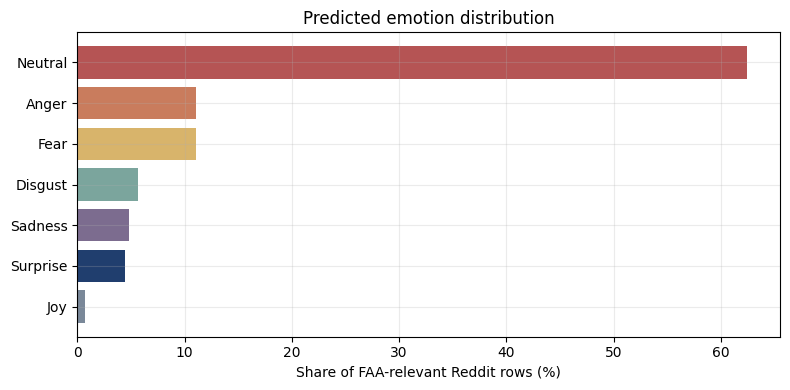

In [37]:
print("EXTRACTING TOP EMOTION")
emotion_records = []
for output in emotion_outputs:
    sorted_scores = sorted(
        [(row["label"].lower(), row["score"]) for row in output],
        key=lambda pair: pair[1],
        reverse=True,
    )
    label, confidence = sorted_scores[0]
    second_best_emotion, second_best_score = sorted_scores[1]
    emotion_records.append(
        {
            "emotion": label,
            "emotion_confidence": confidence,
            "second_best_emotion": second_best_emotion,
            "second_best_score": second_best_score,
            "emotion_margin": confidence - second_best_score,
            "scores": dict(sorted_scores),
        }
    )

df["emotion"] = [row["emotion"] for row in emotion_records]
df["emotion_confidence"] = [row["emotion_confidence"] for row in emotion_records]
df["second_best_emotion"] = [row["second_best_emotion"] for row in emotion_records]
df["second_best_score"] = [row["second_best_score"] for row in emotion_records]
df["emotion_margin"] = [row["emotion_margin"] for row in emotion_records]

emotion_share = (
    df["emotion"].value_counts(normalize=True).sort_values(ascending=False).mul(100).round(1)
)
display(emotion_share.rename_axis("emotion").reset_index(name="share_pct"))

plt.figure(figsize=(8, 4))
plt.barh(emotion_share.index.str.title(), emotion_share.values, color=[RED, SECONDARY, GOLD, ACCENT, PURPLE, PRIMARY, "#7A8899"][: len(emotion_share)])
plt.gca().invert_yaxis()
plt.xlabel("Share of FAA-relevant Reddit rows (%)")
plt.title("Predicted emotion distribution")
plt.tight_layout()
plt.show()


#### 14.5. Representative Reddit rows by emotion


In [38]:
emotion_priority = ["anger", "fear", "sadness", "disgust", "surprise", "joy", "neutral"]
emotion_priority_lookup = {label: idx for idx, label in enumerate(emotion_priority)}

representative_emotion_rows = (
    df[["text", "emotion", "emotion_confidence", "emotion_margin", "community_name", "username", "upvotes"]]
    .assign(emotion_rank=lambda frame: frame["emotion"].map(emotion_priority_lookup).fillna(99))
    .sort_values(["emotion_rank", "emotion_confidence", "emotion_margin", "upvotes"], ascending=[True, False, False, False])
    .groupby("emotion")
    .head(4)
    .assign(text_excerpt=lambda frame: frame["text"].str.replace("\n", " ", regex=False).str.slice(0, 220))
    .drop(columns="text")
    .reset_index(drop=True)
)
representative_emotion_rows


,emotion,emotion_confidence,emotion_margin,community_name,username,upvotes,emotion_rank,text_excerpt
0,anger,0.960,0.942,r/interesting,FblthpLives,1,0,"I realize I'm going to be downvoted into oblivion, but LGA running a combined position for local and ground control predates Trump. I am also angry at Trump, but so many here are trying to make this out about Trump s..."
1,anger,0.949,0.928,r/interesting,green5275,1,0,"Pilots Antoine Forest and MacKenzie Gunther, RIP😔…🤦🏻‍♂️😡🤬FFS THIS IS LITERALLY WHAT HAPPENS WHEN YOU PUSH AIR TRAFFIC CONTROLLERS BEYOND THEIR LIMITS… I have no doubt in my mind that Trump’s FAA budget cuts, and “ant..."
2,anger,0.937,0.900,r/news,_head_,9,0,"I would have thought all these French speaking Canadians would be focusing their righteous indignation on the FAA in the US for under staffing ATC for years and causing the deaths of these pilots... but no, that guy ..."
3,anger,0.919,0.895,r/SanDiego_California,Holiday-Positive-334,1,0,"[Air traffic controllers slam Congress over shutdown | NBC 7 San Diego](https://www.youtube.com/watch?v=Y2SUNaQ3Hb8) *""The National Air Traffic Controllers Association blasted Congress over the prolonged government s..."
4,fear,0.974,0.964,r/AskALiberal,srv340mike,1,1,&gt; The CCTV video that came out shows the lights on. clearly a loss of situational awareness by the crew of the truck had occurred. His panic toned happened after he had told it to hold and stop calmly a couple of ...
5,fear,0.967,0.953,r/fearofflying,DudeIBangedUrMom,7,1,"&gt; I've seen a lot of Americans saying that they won't get on a plane because it's not safe under the current administration. Yet we're all still out there, safely operating ~50,000 flights a day in the US, just ..."
6,fear,0.960,0.945,r/canada,leoyvr,2,1,Didn’t Trump administration make cut backs to air traffic controllers?? I checked out Aviation-Safety.net. What is scary is USA fatalities are higher than other countries like China. I’m not flying to US anytime so...
7,fear,0.956,0.936,r/travel,Additional_Cat9161,-1,1,"Air travel in america is becoming more and more unsafe. With airlines cutting corners on maintenance, FAA budget cuts, and now airports becoming less functional because of the government shutdown, I would rather not ..."
8,sadness,0.962,0.947,r/aviation,SubarcticFarmer,-1,2,"It's been a while since I looked into it, but the V-22 is significantly more dangerous than a helicopter. The current estimate is 7 catastrophic failures per million flight hours. The military ""minimum standard""..."
9,sadness,0.946,0.917,r/atc2,xPericulantx,9,2,Well this next generation of controllers will unequivocally need a second career after completing their ATC career. Really sad state of affairs. Edit: OKC will be max staffed and those wages will fall drastically b...


In [39]:
non_neutral_emotion_examples = (
    df[df["emotion"] != "neutral"][["text", "emotion", "emotion_confidence", "emotion_margin", "community_name", "username", "upvotes"]]
    .assign(emotion_rank=lambda frame: frame["emotion"].map(emotion_priority_lookup).fillna(99))
    .sort_values(["emotion_rank", "emotion_confidence", "emotion_margin", "upvotes"], ascending=[True, False, False, False])
    .groupby("emotion")
    .head(5)
    .assign(text_excerpt=lambda frame: frame["text"].str.replace("\n", " ", regex=False).str.slice(0, 180))
    .drop(columns="text")
    .reset_index(drop=True)
)
non_neutral_emotion_examples


,emotion,emotion_confidence,emotion_margin,community_name,username,upvotes,emotion_rank,text_excerpt
0,anger,0.960,0.942,r/interesting,FblthpLives,1,0,"I realize I'm going to be downvoted into oblivion, but LGA running a combined position for local and ground control predates Trump. I am also angry at Trump, but so many here are t"
1,anger,0.949,0.928,r/interesting,green5275,1,0,"Pilots Antoine Forest and MacKenzie Gunther, RIP😔…🤦🏻‍♂️😡🤬FFS THIS IS LITERALLY WHAT HAPPENS WHEN YOU PUSH AIR TRAFFIC CONTROLLERS BEYOND THEIR LIMITS… I have no doubt in my mind th"
2,anger,0.937,0.900,r/news,_head_,9,0,I would have thought all these French speaking Canadians would be focusing their righteous indignation on the FAA in the US for under staffing ATC for years and causing the deaths
3,anger,0.919,0.895,r/SanDiego_California,Holiday-Positive-334,1,0,"[Air traffic controllers slam Congress over shutdown | NBC 7 San Diego](https://www.youtube.com/watch?v=Y2SUNaQ3Hb8) *""The National Air Traffic Controllers Association blasted Cong"
4,anger,0.913,0.871,r/aviation,Pacer17,64,0,Im most angry at the system. As a 121 captain i can say we have faults and this is one of those swiss cheese model events i hope to drive change. Think about the situation here: P
5,fear,0.974,0.964,r/AskALiberal,srv340mike,1,1,&gt; The CCTV video that came out shows the lights on. clearly a loss of situational awareness by the crew of the truck had occurred. His panic toned happened after he had told it
6,fear,0.967,0.953,r/fearofflying,DudeIBangedUrMom,7,1,"&gt; I've seen a lot of Americans saying that they won't get on a plane because it's not safe under the current administration. Yet we're all still out there, safely operating ~5"
7,fear,0.960,0.945,r/canada,leoyvr,2,1,Didn’t Trump administration make cut backs to air traffic controllers?? I checked out Aviation-Safety.net. What is scary is USA fatalities are higher than other countries like Chi
8,fear,0.956,0.936,r/travel,Additional_Cat9161,-1,1,"Air travel in america is becoming more and more unsafe. With airlines cutting corners on maintenance, FAA budget cuts, and now airports becoming less functional because of the gove"
9,fear,0.947,0.928,r/flying,rFlyingTower,1,1,This is a copy of the original post body for posterity: --- I picked up some experience over my 300hrs of flying. Most of that being on a C152 that i own. I also very much like


In [40]:
top_non_neutral_table = (
    df[df["emotion"] != "neutral"][["text", "emotion", "emotion_confidence", "emotion_margin", "community_name"]]
    .sort_values(["emotion_confidence", "emotion_margin"], ascending=False)
    .head(12)
    .assign(text_excerpt=lambda frame: frame["text"].str.replace("\n", " ", regex=False).str.slice(0, 180))
    .drop(columns="text")
    .reset_index(drop=True)
)
top_non_neutral_table


,emotion,emotion_confidence,emotion_margin,community_name,text_excerpt
0,surprise,0.980,0.971,r/fednews,Went to an aviation university and wanted to become air traffic controller but was surprised how the government just never recruited or even handed out pamphlets or nothing. This w
1,fear,0.974,0.964,r/AskALiberal,&gt; The CCTV video that came out shows the lights on. clearly a loss of situational awareness by the crew of the truck had occurred. His panic toned happened after he had told it
2,disgust,0.968,0.958,r/ThatsInsane,"Nah, it checks out. He has gotta cover his ass between firing so many people who work in aviation safety and then the govt shutting down for the longest time since his last shutdo"
3,fear,0.967,0.953,r/fearofflying,"&gt; I've seen a lot of Americans saying that they won't get on a plane because it's not safe under the current administration. Yet we're all still out there, safely operating ~5"
4,sadness,0.962,0.947,r/aviation,"It's been a while since I looked into it, but the V-22 is significantly more dangerous than a helicopter. The current estimate is 7 catastrophic failures per million flight hours"
5,surprise,0.961,0.946,r/ATC,"&gt;Agency officials blame a combination of attrition, the length of time that it takes to train controllers, and historically high washout rate for the slow progress. But they als"
6,anger,0.960,0.942,r/interesting,"I realize I'm going to be downvoted into oblivion, but LGA running a combined position for local and ground control predates Trump. I am also angry at Trump, but so many here are t"
7,fear,0.960,0.945,r/canada,Didn’t Trump administration make cut backs to air traffic controllers?? I checked out Aviation-Safety.net. What is scary is USA fatalities are higher than other countries like Chi
8,fear,0.956,0.936,r/travel,"Air travel in america is becoming more and more unsafe. With airlines cutting corners on maintenance, FAA budget cuts, and now airports becoming less functional because of the gove"
9,surprise,0.952,0.935,r/NoStupidQuestions,"My reply from the other comment here: Wow, my comment got seriously misconstrued here. I don’t want another space race that just makes us dump extra money into NASA for a short pe"


#### 14.6. Emotion by theme


emotion,anger,disgust,fear,joy,neutral,sadness,surprise
plot_theme,,,,,,,
incident,0.080,0.040,0.180,0.000,0.620,0.050,0.040
operations,0.120,0.030,0.140,0.020,0.580,0.070,0.050
other,0.110,0.070,0.030,0.010,0.620,0.070,0.090
recruitment,0.380,0.120,0.000,0.000,0.380,0.060,0.060
safety_oversight,0.090,0.050,0.100,0.010,0.690,0.030,0.030
staffing,0.110,0.070,0.040,0.000,0.670,0.070,0.040
working_conditions,0.160,0.130,0.030,0.000,0.600,0.030,0.060


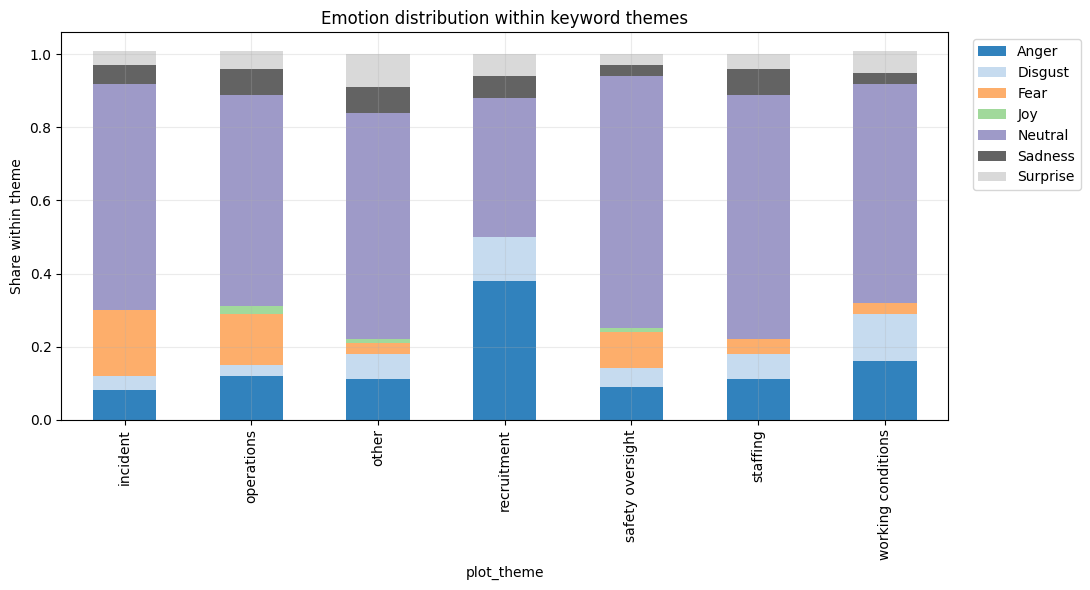

In [41]:
emotion_theme_pct = pd.crosstab(
    df["plot_theme"],
    df["emotion"],
    normalize="index",
).round(2)

display(emotion_theme_pct)

emotion_theme_plot = emotion_theme_pct.copy()
emotion_theme_plot.index = emotion_theme_plot.index.str.replace("_", " ")
emotion_theme_plot.columns = [col.title() for col in emotion_theme_plot.columns]
emotion_theme_plot.plot(kind="bar", stacked=True, figsize=(11, 6), colormap="tab20c")
plt.ylabel("Share within theme")
plt.title("Emotion distribution within keyword themes")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


The emotion labels do not replace close reading, but they provide a useful sentiment-oriented summary of the corpus. The clearest pattern is that Reddit remains mostly neutral overall, with fear and anger rising around incidents and staffing stress.
